In [2]:
!pip install transformers torch

In [2]:
import torch
from transformers import BertTokenizer
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.notebook import tqdm
from torchvision import transforms
import torch.nn as nn
from torchvision import models
from transformers import BertModel,BertTokenizer
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report


In [4]:
data=pd.read_csv('labels_front.csv')
data.head()

,image_id,caption,path,gender,product_type,product_id,image_type
0,MEN-Denim-id_00000089-28_1_front,This gentleman is wearing a medium-sleeve shir...,MEN-Denim-id_00000089-28_1_front.jpg,MEN,Denim,id_00000089,front
1,MEN-Denim-id_00000265-01_1_front,This person is wearing a short-sleeve shirt wi...,MEN-Denim-id_00000265-01_1_front.jpg,MEN,Denim,id_00000265,front
2,MEN-Denim-id_00000313-01_1_front,The gentleman is wearing a short-sleeve T-shir...,MEN-Denim-id_00000313-01_1_front.jpg,MEN,Denim,id_00000313,front
3,MEN-Denim-id_00000516-01_1_front,The person wears a sleeveless tank shirt with ...,MEN-Denim-id_00000516-01_1_front.jpg,MEN,Denim,id_00000516,front
4,MEN-Denim-id_00000750-01_1_front,"His sweater has long sleeves, cotton fabric an...",MEN-Denim-id_00000750-01_1_front.jpg,MEN,Denim,id_00000750,front


In [3]:
data.drop(columns=['image_id', 'gender','product_id','image_type'],inplace=True)
data.head()

,caption,path,product_type
0,This gentleman is wearing a medium-sleeve shir...,MEN-Denim-id_00000089-28_1_front.jpg,Denim
1,This person is wearing a short-sleeve shirt wi...,MEN-Denim-id_00000265-01_1_front.jpg,Denim
2,The gentleman is wearing a short-sleeve T-shir...,MEN-Denim-id_00000313-01_1_front.jpg,Denim
3,The person wears a sleeveless tank shirt with ...,MEN-Denim-id_00000516-01_1_front.jpg,Denim
4,"His sweater has long sleeves, cotton fabric an...",MEN-Denim-id_00000750-01_1_front.jpg,Denim


## Text Preprocessing

In [2]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
sample_text = ""
encoded_input = tokenizer(
    sample_text,
    padding='max_length',    # Padding using Zeros
    max_length=16,           # Max length of tokens
    truncation=True,         # Crop any tokens more than the max length
    return_tensors='pt'      # to tensors direct
)

## Image Preprocessing

In [3]:

class DeepFashionTransforms:

    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]

    def __init__(self, img_size=256, crop_size=224):
        self.img_size  = img_size
        self.crop_size = crop_size

    def train_transform(self):
        return transforms.Compose([
            transforms.Resize(self.img_size),
            transforms.RandomResizedCrop(self.crop_size, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize(self.IMAGENET_MEAN, self.IMAGENET_STD)
        ])

    def val_transform(self):
        return transforms.Compose([
            transforms.Resize(self.img_size),
            transforms.CenterCrop(self.crop_size),
            transforms.ToTensor(),
            transforms.Normalize(self.IMAGENET_MEAN, self.IMAGENET_STD)
        ])

    # alias so test uses the same pipeline as val
    def test_transform(self):
        return self.val_transform()




## Dataset splitting

In [18]:
class DeepFashionDataset(Dataset):

    def __init__(self, root, split="train", transform=None,
                 csv_path='labels_front.csv',
                 tokenizer=None, max_length=64,
                 val_ratio=0.1, test_ratio=0.1, random_state=42):

        self.root       = root
        self.transform  = transform
        self.tokenizer  = tokenizer
        self.max_length = max_length

        df = pd.read_csv(csv_path)
        df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)

        # ✅ Add this — filter out rows where image file doesn't exist
        df = df[df["path"].apply(lambda p: os.path.exists(os.path.join(root, p)))]
        df = df.reset_index(drop=True)

        print(f"[{split}] {len(df)} samples after filtering missing images")

        n      = len(df)
        n_test = int(n * test_ratio)
        n_val  = int(n * val_ratio)

        if split == "test":
            df = df.iloc[:n_test]
        elif split == "val":
            df = df.iloc[n_test : n_test + n_val]
        else:
            df = df.iloc[n_test + n_val :]

        self.data = df.reset_index(drop=True)

        # label encoder built from the full CSV so all splits share same mapping
        all_df = pd.read_csv(csv_path)
        all_classes       = sorted(all_df["product_type"].unique())
        self.class_to_idx = {c: i for i, c in enumerate(all_classes)}
        self.num_classes  = len(all_classes)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row     = self.data.iloc[idx]
        # --- image ---
        img_path = os.path.join(self.root, row["path"])
        image    = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # --- text ---
        encoding = self.tokenizer(
            row["caption"],
            padding="max_length",
            max_length=self.max_length,
            truncation=True,
            return_tensors="pt"
        )
        input_ids      = encoding["input_ids"].squeeze(0)       # (max_length,)
        attention_mask = encoding["attention_mask"].squeeze(0)  # (max_length,)

        # --- label ---
        label = self.class_to_idx[row["product_type"]]

        return image, input_ids, attention_mask, label

## Grad-CAM for ResNET

In [7]:
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None

        target_layer = self.model.img_encoder.layer4

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient) 

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, class_idx):
        grads = self.gradients          # (B, C, H, W)
        acts  = self.activations        # (B, C, H, W)

        # Global average pooling on gradients
        weights = grads.mean(dim=(2, 3), keepdim=True)   # (B, C, 1, 1)

        # Weighted sum of activations
        cam = (weights * acts).sum(dim=1)                # (B, H, W)

        # Apply ReLU
        cam = torch.relu(cam)

        # Take first sample in batch
        cam = cam[0]

        # Convert to numpy
        cam = cam.detach().cpu().numpy()

        # Normalize
        cam = (cam - cam.min()) / (cam.max() + 1e-8)

        return cam

## Integrated Gradients for BERT

In [8]:
def integrated_gradients(model, images, input_ids, attention_mask, target_class, steps=50):
    model.eval()

    embeddings = model.txt_encoder.embeddings(input_ids)

    baseline = torch.zeros_like(embeddings)

    scaled_inputs = [
        baseline + (float(i) / steps) * (embeddings - baseline)
        for i in range(steps + 1)
    ]

    grads = []

    for i in range(steps + 1):
        alpha = float(i) / steps
    
        scaled = baseline + alpha * (embeddings - baseline)
        scaled = scaled.clone().detach().requires_grad_(True)
    
        outputs = model(
            images=images,
            input_ids=input_ids,
            attention_mask=attention_mask,
            embedded_text=scaled
        )
    
        # correct class selection
        loss = outputs.gather(1, target_class.unsqueeze(1)).sum()
    
        model.zero_grad()
        loss.backward()   
    
        grads.append(scaled.grad.detach())

    avg_grads = torch.stack(grads).mean(dim=0)
    attributions = (embeddings - baseline) * avg_grads

    token_importance = attributions.sum(dim=-1).squeeze()

    return token_importance

# Intermediate Fusion (using CNN)

In [9]:

class CrossModalAttention(nn.Module):
    """
    One direction of cross-attention:
      query  comes from modality A  (shape: B, 1, dim)  — the single global token
      key/value come from modality B  (shape: B, seq_len, dim) — the full sequence

    For image→text: image queries the full BERT token sequence
    For text→image: [CLS] token queries the image spatial feature (treated as seq of 1)
    """
    def __init__(self, dim, num_heads=8, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True      # (B, seq, dim) convention
        )
        self.norm    = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(dropout)
        self.last_attn_weights = None

    def forward(self, query, key_value, key_padding_mask=None):
        """
        query        : (B, 1,       dim)
        key_value    : (B, seq_len, dim)
        Returns      : (B, 1,       dim)  — query enriched with context from key_value
        """
        attended, attn_weights = self.attn(
            query, key_value, key_value,
            key_padding_mask=key_padding_mask,
            need_weights=True,
            average_attn_weights=False
        )
        
        # store for XAI
        self.last_attn_weights = attn_weights
        
        # residual + norm
        out = self.norm(query + self.dropout(attended))
        return out                              # (B, 1, dim)


class IntermediateFusionModel(nn.Module):
  

    def __init__(self, num_classes, proj_dim=512, num_heads=8, dropout=0.3):
        super().__init__()

        # ── Image encoder ────────────────────────────────────────────────
        backbone     = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        img_feat_dim = backbone.fc.in_features          # 2048
        backbone.fc  = nn.Identity()
        self.img_encoder = backbone

        self.img_proj = nn.Sequential(
            nn.Linear(img_feat_dim, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ── Text encoder ─────────────────────────────────────────────────
        self.txt_encoder = BertModel.from_pretrained("bert-base-uncased")
        txt_feat_dim     = self.txt_encoder.config.hidden_size   # 768

        self.txt_proj = nn.Linear(txt_feat_dim, proj_dim)        # project every token
        self.txt_norm = nn.LayerNorm(proj_dim)

        # ── Bidirectional cross-attention ─────────────────────────────────
        # Direction 1: image global feature queries the full text sequence
        self.img_attends_txt = CrossModalAttention(proj_dim, num_heads, dropout)

        # Direction 2: text [CLS] token queries the image global feature
        self.txt_attends_img = CrossModalAttention(proj_dim, num_heads, dropout)

        # ── Classifier ───────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim * 2, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(proj_dim, num_classes)
        )

    def forward(self, images, input_ids, attention_mask, embedded_text=None):
        # ── Image branch ─────────────────────────────────────────────────
        img_feat = self.img_encoder(images)          # (B, 2048)
        img_feat = self.img_proj(img_feat)           # (B, 512)
        img_seq  = img_feat.unsqueeze(1)             # (B, 1, 512)  treat as seq of 1

        # ── Text branch ──────────────────────────────────────────────────
        if embedded_text is not None:
            bert_out = self.txt_encoder(
                inputs_embeds=embedded_text,
                attention_mask=attention_mask
            )
        else:
            bert_out = self.txt_encoder(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
        txt_tokens = bert_out.last_hidden_state      # (B, seq_len, 768)
        txt_tokens = self.txt_norm(
            self.txt_proj(txt_tokens)                # (B, seq_len, 512)
        )
        txt_cls    = txt_tokens[:, :1, :]            # (B, 1, 512)  — [CLS] only

        # Convert HuggingFace attention_mask (1=keep, 0=pad)
        # to PyTorch key_padding_mask (True=ignore)
        txt_pad_mask = (attention_mask == 0)         # (B, seq_len)

        # ── Cross-attention (bidirectional) ───────────────────────────────
        # Image global attends to all text tokens
        img_enriched = self.img_attends_txt(
            query=img_seq,
            key_value=txt_tokens,
            key_padding_mask=txt_pad_mask
        ).squeeze(1)                                 # (B, 512)

        # Text [CLS] attends to image feature
        txt_enriched = self.txt_attends_img(
            query=txt_cls,
            key_value=img_seq                        # no padding mask needed
        ).squeeze(1)                                 # (B, 512)

        # ── Fusion + classify ─────────────────────────────────────────────
        fused  = torch.cat([img_enriched, txt_enriched], dim=1)  # (B, 1024)
        logits = self.classifier(fused)                          # (B, num_classes)
        return logits

## Data Loader

In [10]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
transforms_handler = DeepFashionTransforms(img_size=256, crop_size=224)

IMG_ROOT = 'selected_images'
CSV_PATH = 'labels_front.csv'

train_dataset = DeepFashionDataset(IMG_ROOT, split="train",
                                   transform=transforms_handler.train_transform(),
                                   tokenizer=tokenizer, max_length=64,
                                   csv_path=CSV_PATH)

val_dataset   = DeepFashionDataset(IMG_ROOT, split="val",
                                   transform=transforms_handler.val_transform(),
                                   tokenizer=tokenizer, max_length=64,
                                   csv_path=CSV_PATH)

test_dataset  = DeepFashionDataset(IMG_ROOT, split="test",
                                   transform=transforms_handler.test_transform(),
                                   tokenizer=tokenizer, max_length=64,
                                   csv_path=CSV_PATH)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Classes : {train_dataset.num_classes}")
print(f"Train   : {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes : 17
Train   : 9824 | Val: 1227 | Test: 1227


## Saving Results & Plot functions

In [14]:
import json
import os

class TrainingLogger:
    def __init__(self, save_path="training_logs.json"):
        self.save_path = save_path
        self.history = {
            "train_loss": [], "train_acc": [],
            "val_loss":   [], "val_acc":   []
        }

    def log(self, train_loss, train_acc, val_loss, val_acc):
        self.history["train_loss"].append(round(train_loss, 6))
        self.history["train_acc"].append(round(train_acc,  6))
        self.history["val_loss"].append(round(val_loss,   6))
        self.history["val_acc"].append(round(val_acc,     6))
        with open(self.save_path, "w") as f:
            json.dump(self.history, f, indent=2)

    def load(self):
        if os.path.exists(self.save_path):
            with open(self.save_path) as f:
                self.history = json.load(f)
        return self.history

### Plotting the learning curve, Loss curve & Roc curve

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


def plot_learning_curve(history, save_path="learning_curve.png"):
    epochs = range(1, len(history["train_acc"]) + 1)
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(epochs, history["train_acc"], "o-",  color="#378ADD", lw=2, label="Train")
    ax.plot(epochs, history["val_acc"],   "s--", color="#1D9E75", lw=2, label="Val")

    # shade the overfitting gap
    ax.fill_between(epochs, history["train_acc"], history["val_acc"],
                    alpha=0.08, color="#D85A30", label="Gap")

    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Accuracy", fontsize=12)
    ax.set_title("Learning curve — accuracy", fontsize=13, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
    ax.set_ylim(max(0, min(history["train_acc"] + history["val_acc"]) - 0.05), 1.02)
    ax.set_xticks(list(epochs))
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")


def plot_loss_curve(history, save_path="loss_curve.png"):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(epochs, history["train_loss"], "o-",  color="#378ADD", lw=2, label="Train")
    ax.plot(epochs, history["val_loss"],   "s--", color="#1D9E75", lw=2, label="Val")

    ax.fill_between(epochs, history["train_loss"], history["val_loss"],
                    alpha=0.08, color="#D85A30", label="Gap")

    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Loss", fontsize=12)
    ax.set_title("Loss curve", fontsize=13, fontweight="bold")
    ax.set_xticks(list(epochs))
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")


def plot_roc_curves(model, loader, dataset, device, save_path="roc_curves.png"):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, input_ids, attention_mask, labels in loader:
            images         = images.to(device)
            input_ids      = input_ids.to(device)
            attention_mask = attention_mask.to(device)

            logits = model(images, input_ids, attention_mask)
            probs  = torch.softmax(logits, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)

    idx_to_class   = {v: k for k, v in dataset.class_to_idx.items()}
    present_labels = sorted(set(all_labels))
    y_bin          = label_binarize(all_labels, classes=present_labels)
    n_classes      = len(present_labels)
    colors         = plt.cm.tab20(np.linspace(0, 1, n_classes))

    fig, ax = plt.subplots(figsize=(10, 8))

    mean_fpr = np.linspace(0, 1, 200)
    tprs, aucs = [], []

    for i, cls_idx in enumerate(present_labels):
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, cls_idx])
        roc_auc     = auc(fpr, tpr)
        aucs.append(roc_auc)
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        ax.plot(fpr, tpr, color=colors[i], lw=1.5,
                label=f"{idx_to_class[cls_idx]}  (AUC={roc_auc:.2f})")

    # macro-average ROC
    mean_tpr      = np.mean(tprs, axis=0)
    mean_tpr[0]   = 0.0
    mean_tpr[-1]  = 1.0
    macro_auc     = auc(mean_fpr, mean_tpr)
    ax.plot(mean_fpr, mean_tpr, color="black", lw=2.5, linestyle=":",
            label=f"Macro avg  (AUC={macro_auc:.2f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random  (AUC=0.50)")

    ax.set_xlabel("False positive rate", fontsize=12)
    ax.set_ylabel("True positive rate",  fontsize=12)
    ax.set_title("ROC curves — per class (one-vs-rest)", fontsize=13, fontweight="bold")
    ax.legend(loc="lower right", fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")

## Training Loop

In [29]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.notebook import tqdm

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 20

model     = IntermediateFusionModel(num_classes=train_dataset.num_classes).to(DEVICE)
logger    = TrainingLogger(save_path="training_logs.json")
criterion = nn.CrossEntropyLoss()

for param in model.txt_encoder.parameters():
    param.requires_grad = False

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-2)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)


def run_epoch(loader, train=True, epoch=0):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    phase = "Train" if train else "Val"
    pbar  = tqdm(loader, desc=f"Epoch {epoch:02d} [{phase}]", leave=False)

    with torch.set_grad_enabled(train):
        for images, input_ids, attention_mask, labels in pbar:
            images, input_ids      = images.to(DEVICE), input_ids.to(DEVICE)
            attention_mask, labels = attention_mask.to(DEVICE), labels.to(DEVICE)

            logits = model(images, input_ids, attention_mask)
            loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * labels.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)
            pbar.set_postfix({"loss": f"{total_loss/total:.4f}",
                              "acc":  f"{correct/total:.4f}"})

    return total_loss / total, correct / total
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    if epoch == 4:
        for param in model.txt_encoder.parameters():
            param.requires_grad = True
        optimizer.add_param_group({"params": model.txt_encoder.parameters(), "lr": 2e-5})

    train_loss, train_acc = run_epoch(train_loader, train=True,  epoch=epoch)
    val_loss,   val_acc   = run_epoch(val_loader,   train=False, epoch=epoch)
    scheduler.step()

    # ── log & print ──────────────────────────────────────────────────────
    logger.log(train_loss, train_acc, val_loss, val_acc)
    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")
    # ── SAVE BEST MODEL ─────────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
    
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": val_acc
        }, "best_model_CNN.pth")
    
        print(f"Saved new best model at epoch {epoch} with val_acc={val_acc:.4f}")

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "val_acc": val_acc
    }, "last_model_CNN.pth")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 [Train]:   0%|          | 0/307 [00:00<?, ?it/s]

Epoch 01 [Val]:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 1.4070  Acc: 0.5365 | Val Loss: 0.9479  Acc: 0.6911
Saved new best model at epoch 1 with val_acc=0.6911


...

Epoch 19 [Val]:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 19 | Train Loss: 0.0266  Acc: 0.9924 | Val Loss: 1.1067  Acc: 0.7914


Epoch 20 [Train]:   0%|          | 0/307 [00:00<?, ?it/s]

Epoch 20 [Val]:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 20 | Train Loss: 0.0253  Acc: 0.9927 | Val Loss: 1.1079  Acc: 0.7905


## Best Model Loading

In [31]:
model = IntermediateFusionModel(
    num_classes=train_dataset.num_classes
).to(DEVICE)

checkpoint = torch.load('best_model_CNN.pth', map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>

## XAI

In [32]:
model.eval()
grad_cam = GradCAM(model)

images, input_ids, attention_mask, labels = next(iter(val_loader))
images = images.to(DEVICE)
input_ids = input_ids.to(DEVICE)
attention_mask = attention_mask.to(DEVICE)

images.requires_grad = True

# forward
logits = model(images, input_ids, attention_mask)
pred_class = logits.argmax(dim=1)

# backward for Grad-CAM
loss = logits[:, pred_class].sum()
model.zero_grad()
loss.backward()

# ── Grad-CAM
cam = grad_cam.generate(pred_class[0])

# ── Attention
attn_weights = model.img_attends_txt.last_attn_weights

# ── Integrated Gradients
token_importance = integrated_gradients(
    model, images, input_ids, attention_mask, pred_class
)

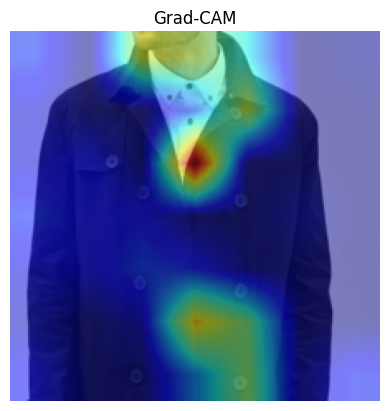

In [42]:
import matplotlib.pyplot as plt
import cv2
import random
# image
img = images[random.randint(0,20)].detach().cpu().permute(1,2,0).numpy()

# unnormalize
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
img = img * std + mean
img = img.clip(0, 1)

# CAM 
cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))

plt.imshow(img)
plt.imshow(cam_resized, cmap='jet', alpha=0.5)
plt.title("Grad-CAM")
plt.axis('off')
plt.show()

In [43]:
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

scores = token_importance[0] 

for tok, score in zip(tokens, scores):
    print(f"{tok}: {score.item():.4f}")

[CLS]: -0.0416
the: 0.1128
lady: 0.0854
wears: 0.1085
a: 0.0405
sleeve: 0.0515
##less: -0.0421
tank: 0.0419
top: 0.0202
with: 0.0800
pure: -0.0174
color: -0.0473
patterns: -0.0416
and: -0.0008
a: -0.0245
three: -0.1782
-: -0.0222
point: -0.1289
shorts: -0.2226
.: -0.0118
the: 0.0894
tank: -0.0249
top: -0.0090
is: -0.0109
with: -0.0252
chi: -0.1012
##ff: 0.2299
##on: 0.2443
fabric: -0.2755
.: 0.1119
the: 0.0468
neck: 0.0487
##line: -0.0210
of: 0.0804
the: 0.0282
tank: -0.0061
top: -0.0411
is: -0.0072
suspend: 0.0088
##ers: 0.0533
.: 0.0696
the: 0.0886
shorts: -0.0812
are: 0.0557
with: 0.0436
chi: -0.0804
##ff: 0.4940
##on: 0.4633
fabric: -0.2427
and: 0.0398
solid: 0.0397
color: -0.0178
patterns: -0.0791
.: 0.1504
the: 0.1169
female: 0.1719
is: 0.0090
wearing: 0.1042
a: 0.1494
ring: 0.1158
on: -0.0049
her: -0.0358
finger: -0.0141
[SEP]: 0.1808


In [44]:
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
scores = token_importance[0].detach().cpu().numpy()

# Remove special tokens
filtered = [(t, s) for t, s in zip(tokens, scores)
            if t not in ['[CLS]', '[SEP]', '[PAD]', '.', ',', ':']]

tokens, scores = zip(*filtered)

# Normalize
scores = (scores - min(scores)) / (max(scores) + 1e-8)

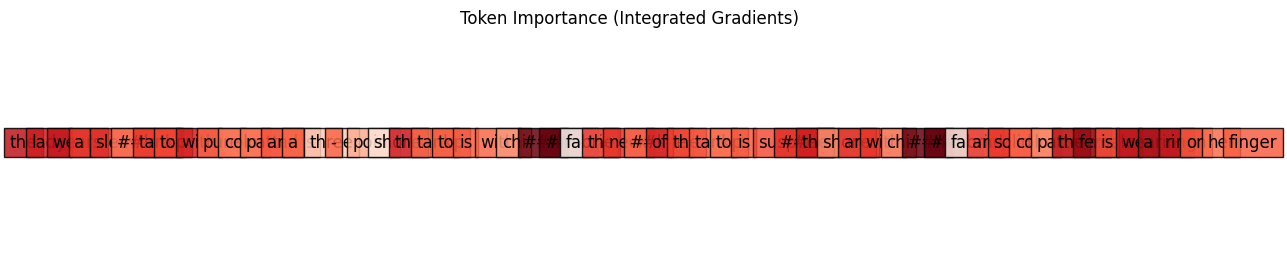

In [45]:
plt.figure(figsize=(16, 3))

x = 0
for tok, score in zip(tokens, scores):
    plt.text(x, 0, tok,
             fontsize=12,
             bbox=dict(facecolor=plt.cm.Reds(score), alpha=0.85),
             ha='left')
    x += 1.2   # fixed spacing → cleaner

plt.xlim(0, x)
plt.ylim(-1, 1)
plt.axis('off')
plt.title("Token Importance (Integrated Gradients)")
plt.show()

In [46]:
attn = attn_weights[0].mean(0).squeeze()  # avg heads

for tok, score in zip(tokens, attn):
    print(f"{tok}: {score.item():.4f}")

the: 0.0028
lady: 0.0049
wears: 0.0032
a: 0.0003
sleeve: 0.0004
##less: 0.0006
tank: 0.0007
top: 0.0007
with: 0.0008
pure: 0.0013
color: 0.0008
patterns: 0.0004
and: 0.0011
a: 0.0023
three: 0.0009
-: 0.0025
point: 0.0017
shorts: 0.0018
the: 0.0056
tank: 0.0008
top: 0.0005
is: 0.0006
with: 0.0010
chi: 0.0020
##ff: 0.0062
##on: 0.1580
fabric: 0.0514
the: 0.0610
neck: 0.0100
##line: 0.0008
of: 0.0018
the: 0.0038
tank: 0.0028
top: 0.0038
is: 0.0009
suspend: 0.0009
##ers: 0.0016
the: 0.0027
shorts: 0.0032
are: 0.0025
with: 0.0008
chi: 0.0032
##ff: 0.0216
##on: 0.0065
fabric: 0.0156
and: 0.2572
solid: 0.1030
color: 0.1304
patterns: 0.0671
the: 0.0210
female: 0.0070
is: 0.0026
wearing: 0.0035
a: 0.0008
ring: 0.0005
on: 0.0013
her: 0.0004
finger: 0.0007


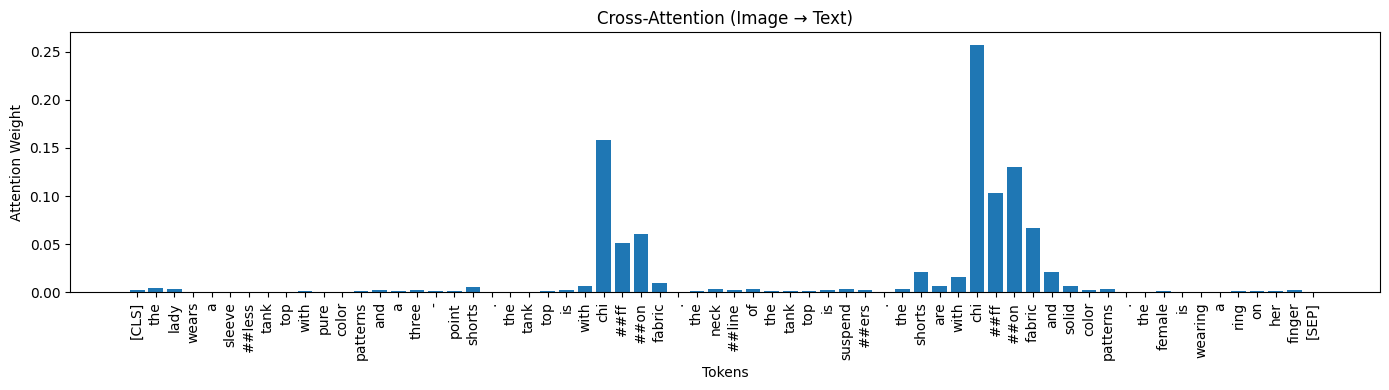

In [47]:
import matplotlib.pyplot as plt

tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
attn = attn_weights[0].mean(0).squeeze().detach().cpu().numpy()

plt.figure(figsize=(14,4))
plt.bar(range(len(tokens)), attn)

plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.title("Cross-Attention (Image → Text)")
plt.xlabel("Tokens")
plt.ylabel("Attention Weight")

plt.tight_layout()
plt.show()

## Test evaluation

In [48]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, input_ids, attention_mask, labels in test_loader:
        images, input_ids      = images.to(DEVICE), input_ids.to(DEVICE)
        attention_mask, labels = attention_mask.to(DEVICE), labels.to(DEVICE)
        logits = model(images, input_ids, attention_mask)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

idx_to_class = {v: k for k, v in test_dataset.class_to_idx.items()}

# Only use labels that actually appear in the test set
present_labels = sorted(set(all_labels))
target_names   = [idx_to_class[i] for i in present_labels]

print(classification_report(all_labels, all_preds,
                             labels=present_labels,
                             target_names=target_names))

                     precision    recall  f1-score   support

     Blouses_Shirts       0.69      0.81      0.74       181
          Cardigans       0.61      0.60      0.60        47
              Denim       0.38      0.21      0.27        14
            Dresses       0.85      0.86      0.86       191
       Graphic_Tees       0.72      0.70      0.71        33
      Jackets_Coats       0.82      0.73      0.78        45
      Jackets_Vests       0.90      0.60      0.72        15
           Leggings       0.25      0.29      0.27         7
              Pants       0.68      0.82      0.74        51
  Rompers_Jumpsuits       0.73      0.62      0.67        39
       Shirts_Polos       0.62      0.68      0.65        19
             Shorts       0.81      0.61      0.70        88
             Skirts       0.98      0.93      0.95        45
           Sweaters       0.66      0.60      0.63        88
Sweatshirts_Hoodies       0.60      0.62      0.61        24
         Tees_Tanks    

## Curves

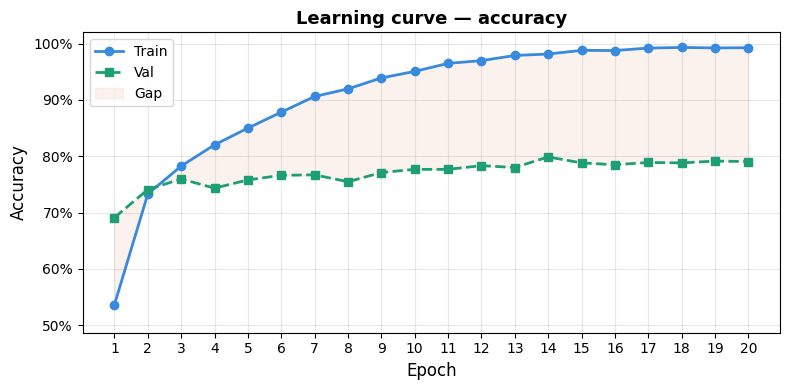

Saved → learning_curve.png


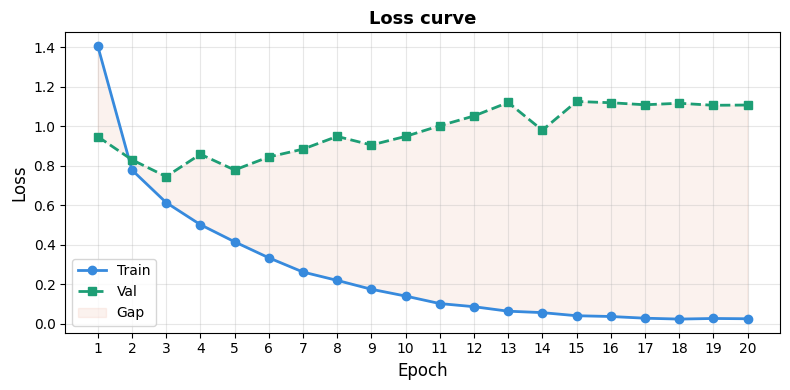

Saved → loss_curve.png


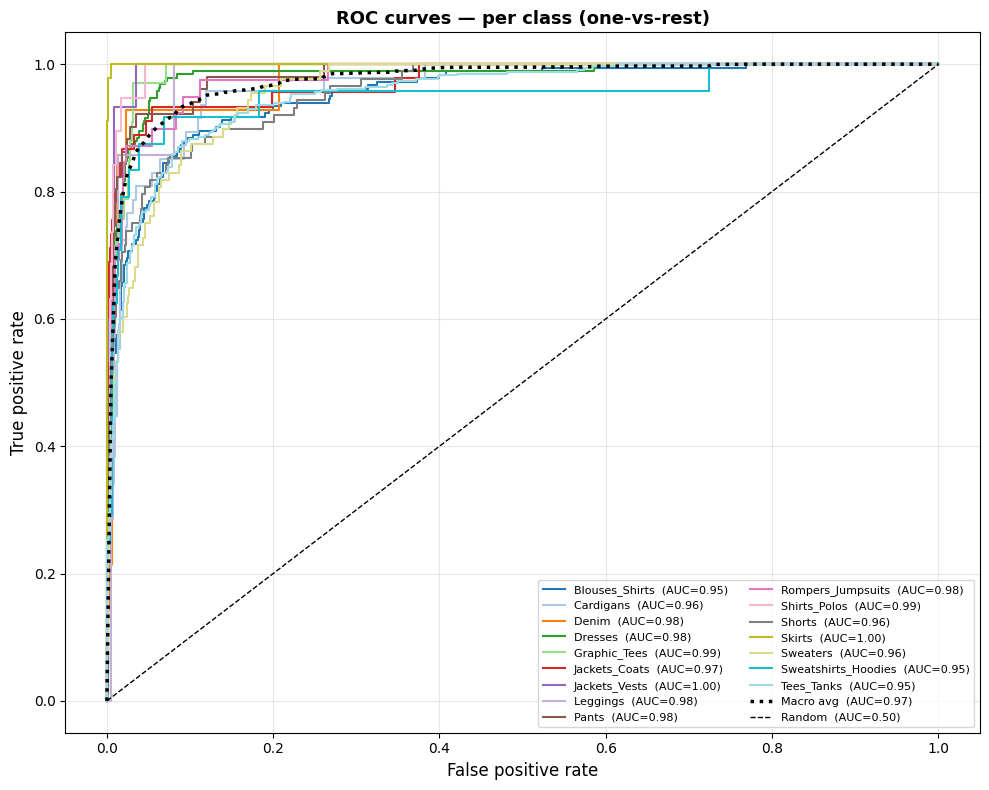

Saved → roc_curves.png


In [49]:
plot_learning_curve(logger.history, save_path="learning_curve.png")
plot_loss_curve(logger.history,     save_path="loss_curve.png")
plot_roc_curves(model, test_loader, test_dataset, DEVICE, save_path="roc_curves.png")

# Intermediate Fusion (Vision Transformer)

## ViTFusion

In [4]:
import torch
import torch.nn as nn
from transformers import BertModel, ViTModel


class CrossModalAttention(nn.Module):
    """Reused from the ResNet model — no changes needed."""
    def __init__(self, dim, num_heads=8, dropout=0.1):
        super().__init__()
        self.attn    = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads,
                                             dropout=dropout, batch_first=True)
        self.norm    = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key_value, key_padding_mask=None):
        attended, _ = self.attn(query, key_value, key_value,
                                key_padding_mask=key_padding_mask)
        return self.norm(query + self.dropout(attended))


class ViTFusionModel(nn.Module):
    """
  
    """

    def __init__(self, num_classes, proj_dim=512, num_heads=8, dropout=0.3):
        super().__init__()

        # ── Image encoder: ViT-B/16 ──────────────────────────────────────
        # hidden size = 768, sequence length = 197 (1 CLS + 196 patches)
        self.img_encoder = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
        vit_hidden_dim   = self.img_encoder.config.hidden_size   # 768

        self.img_proj = nn.Sequential(
            nn.Linear(vit_hidden_dim, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ── Text encoder: BERT-base ───────────────────────────────────────
        self.txt_encoder = BertModel.from_pretrained("bert-base-uncased")
        bert_hidden_dim  = self.txt_encoder.config.hidden_size   # 768

        self.txt_proj = nn.Linear(bert_hidden_dim, proj_dim)
        self.txt_norm = nn.LayerNorm(proj_dim)

        # ── Bidirectional cross-attention ─────────────────────────────────
        # Direction 1: image CLS queries the full text token sequence
        self.img_attends_txt = CrossModalAttention(proj_dim, num_heads, dropout)

        # Direction 2: text CLS queries all 196 image patch tokens
        self.txt_attends_img = CrossModalAttention(proj_dim, num_heads, dropout)

        # ── Classifier ───────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim * 2, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(proj_dim, num_classes)
        )

    def forward(self, images, input_ids, attention_mask):
        # ── Image branch (ViT) ────────────────────────────────────────────
        vit_out     = self.img_encoder(pixel_values=images)
        # last_hidden_state: (B, 197, 768)  — CLS token is index 0
        img_tokens  = self.img_proj(vit_out.last_hidden_state)   # (B, 197, 512)
        img_cls     = img_tokens[:, :1, :]                        # (B,   1, 512)
        img_patches = img_tokens[:, 1:, :]                        # (B, 196, 512)

        # ── Text branch (BERT) ────────────────────────────────────────────
        bert_out   = self.txt_encoder(input_ids=input_ids,
                                      attention_mask=attention_mask)
        txt_tokens = self.txt_norm(
            self.txt_proj(bert_out.last_hidden_state)             # (B, seq_len, 512)
        )
        txt_cls    = txt_tokens[:, :1, :]                         # (B, 1, 512)

        # Convert HuggingFace mask (1=keep, 0=pad) → PyTorch key_padding_mask (True=ignore)
        txt_pad_mask = (attention_mask == 0)                      # (B, seq_len)

        # ── Cross-attention (bidirectional) ───────────────────────────────
        # Image CLS attends to all text tokens
        img_enriched = self.img_attends_txt(
            query=img_cls,
            key_value=txt_tokens,
            key_padding_mask=txt_pad_mask
        ).squeeze(1)                                              # (B, 512)

        # Text CLS attends to all 196 image patch tokens
        txt_enriched = self.txt_attends_img(
            query=txt_cls,
            key_value=img_patches                                 # no padding mask needed
        ).squeeze(1)                                              # (B, 512)

        # ── Fusion + classify ─────────────────────────────────────────────
        fused  = torch.cat([img_enriched, txt_enriched], dim=1)  # (B, 1024)
        logits = self.classifier(fused)                          # (B, num_classes)
        return logits

In [5]:
from torchvision import transforms

# ViT expects exactly 224x224 — no random crop needed since ViT handles spatial variation
vit_train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],   # ViT pretrained on [-1, 1]
                         std=[0.5, 0.5, 0.5])
])

vit_val_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

## Data loader

In [19]:
from torch.utils.data import DataLoader

IMG_ROOT = 'selected_images'
CSV_PATH = 'labels_front.csv'

vit_train_dataset = DeepFashionDataset(IMG_ROOT, split="train",
                                       transform=vit_train_transform,
                                       tokenizer=tokenizer, max_length=64,
                                       csv_path=CSV_PATH)

vit_val_dataset   = DeepFashionDataset(IMG_ROOT, split="val",
                                       transform=vit_val_transform,
                                       tokenizer=tokenizer, max_length=64,
                                       csv_path=CSV_PATH)

vit_test_dataset  = DeepFashionDataset(IMG_ROOT, split="test",
                                       transform=vit_val_transform,
                                       tokenizer=tokenizer, max_length=64,
                                       csv_path=CSV_PATH)

vit_train_loader = DataLoader(vit_train_dataset, batch_size=16, shuffle=True,
                              num_workers=2, pin_memory=True)
vit_val_loader   = DataLoader(vit_val_dataset,   batch_size=16, shuffle=False,
                              num_workers=2, pin_memory=True)
vit_test_loader  = DataLoader(vit_test_dataset,  batch_size=16, shuffle=False,
                              num_workers=2, pin_memory=True)

print(f"Classes : {vit_train_dataset.num_classes}")
print(f"Train   : {len(vit_train_dataset)} | Val: {len(vit_val_dataset)} | Test: {len(vit_test_dataset)}")

[train] 12267 samples after filtering missing images
[val] 12267 samples after filtering missing images
[test] 12267 samples after filtering missing images
Classes : 17
Train   : 9815 | Val: 1226 | Test: 1226


## Training

In [15]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 15

vit_model  = ViTFusionModel(num_classes=17).to(DEVICE)
vit_logger = TrainingLogger(save_path="training_logs_vit.json")
criterion  = nn.CrossEntropyLoss()

# Freeze both ViT and BERT initially
for param in vit_model.img_encoder.parameters():
    param.requires_grad = False
for param in vit_model.txt_encoder.parameters():
    param.requires_grad = False

optimizer = AdamW(filter(lambda p: p.requires_grad, vit_model.parameters()),
                  lr=1e-4, weight_decay=1e-2)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:



def run_epoch_vit(loader, train=True, epoch=0):
    vit_model.train() if train else vit_model.eval()
    total_loss, correct, total = 0.0, 0, 0
    phase = "Train" if train else "Val"
    pbar  = tqdm(loader, desc=f"Epoch {epoch:02d} [{phase}]", leave=False)

    with torch.set_grad_enabled(train):
        for images, input_ids, attention_mask, labels in pbar:
            images, input_ids      = images.to(DEVICE), input_ids.to(DEVICE)
            attention_mask, labels = attention_mask.to(DEVICE), labels.to(DEVICE)

            logits = vit_model(images, input_ids, attention_mask)
            loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * labels.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)
            pbar.set_postfix({"loss": f"{total_loss/total:.4f}",
                              "acc":  f"{correct/total:.4f}"})

    return total_loss / total, correct / total
best_val_acc = 0.0


for epoch in range(1, NUM_EPOCHS + 1):
    # Unfreeze both encoders at epoch 4 with small learning rates
    if epoch == 4:
        for param in vit_model.img_encoder.parameters():
            param.requires_grad = True
        for param in vit_model.txt_encoder.parameters():
            param.requires_grad = True
        optimizer.add_param_group({"params": vit_model.img_encoder.parameters(), "lr": 1e-5})
        optimizer.add_param_group({"params": vit_model.txt_encoder.parameters(), "lr": 2e-5})

    train_loss, train_acc = run_epoch_vit(vit_train_loader, train=True,  epoch=epoch)
    val_loss,   val_acc   = run_epoch_vit(vit_val_loader,   train=False, epoch=epoch)
    scheduler.step()

    vit_logger.log(train_loss, train_acc, val_loss, val_acc)
    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")
    # ── SAVE BEST MODEL ─────────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
    
        torch.save({
            "epoch": epoch,
            "model_state_dict": vit_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": val_acc
        }, "best_model_ViT.pth")
    
        print(f"Saved new best model at epoch {epoch} with val_acc={val_acc:.4f}")

    torch.save({
        "epoch": epoch,
        "model_state_dict": vit_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "val_acc": val_acc
    }, "last_model_ViT.pth")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 [Train]:   0%|          | 0/614 [00:00<?, ?it/s]

Epoch 01 [Val]:   0%|          | 0/77 [00:00<?, ?it/s]

...

Epoch 14 [Val]:   0%|          | 0/77 [00:00<?, ?it/s]

Epoch 14 | Train Loss: 0.0178  Acc: 0.9963 | Val Loss: 0.9208  Acc: 0.8116


Epoch 15 [Train]:   0%|          | 0/614 [00:00<?, ?it/s]

Epoch 15 [Val]:   0%|          | 0/77 [00:00<?, ?it/s]

Epoch 15 | Train Loss: 0.0138  Acc: 0.9981 | Val Loss: 0.9117  Acc: 0.8197


## XAI

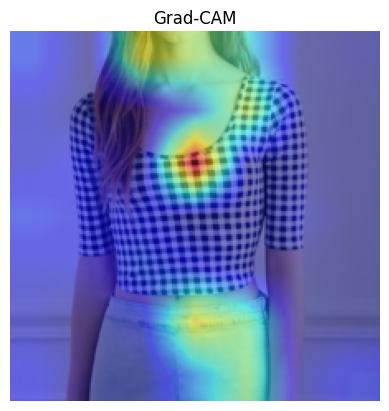

In [67]:
import matplotlib.pyplot as plt
import cv2
import random
# image
img = images[random.randint(0,20)].detach().cpu().permute(1,2,0).numpy()

# unnormalize
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
img = img * std + mean
img = img.clip(0, 1)

# CAM 
cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))

plt.imshow(img)
plt.imshow(cam_resized, cmap='jet', alpha=0.5)
plt.title("Grad-CAM")
plt.axis('off')
plt.show()

In [68]:
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

scores = token_importance[0] 

for tok, score in zip(tokens, scores):
    print(f"{tok}: {score.item():.4f}")

[CLS]: -0.0416
the: 0.1128
lady: 0.0854
wears: 0.1085
a: 0.0405
sleeve: 0.0515
##less: -0.0421
tank: 0.0419
top: 0.0202
with: 0.0800
pure: -0.0174
color: -0.0473
patterns: -0.0416
and: -0.0008
a: -0.0245
three: -0.1782
-: -0.0222
point: -0.1289
shorts: -0.2226
.: -0.0118
the: 0.0894
tank: -0.0249
top: -0.0090
is: -0.0109
with: -0.0252
chi: -0.1012
##ff: 0.2299
##on: 0.2443
fabric: -0.2755
.: 0.1119
the: 0.0468
neck: 0.0487
##line: -0.0210
of: 0.0804
the: 0.0282
tank: -0.0061
top: -0.0411
is: -0.0072
suspend: 0.0088
##ers: 0.0533
.: 0.0696
the: 0.0886
shorts: -0.0812
are: 0.0557
with: 0.0436
chi: -0.0804
##ff: 0.4940
##on: 0.4633
fabric: -0.2427
and: 0.0398
solid: 0.0397
color: -0.0178
patterns: -0.0791
.: 0.1504
the: 0.1169
female: 0.1719
is: 0.0090
wearing: 0.1042
a: 0.1494
ring: 0.1158
on: -0.0049
her: -0.0358
finger: -0.0141
[SEP]: 0.1808


In [69]:
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
scores = token_importance[0].detach().cpu().numpy()

# Remove special tokens
filtered = [(t, s) for t, s in zip(tokens, scores)
            if t not in ['[CLS]', '[SEP]', '[PAD]', '.', ',', ':']]

tokens, scores = zip(*filtered)

# Normalize
scores = (scores - min(scores)) / (max(scores) + 1e-8)

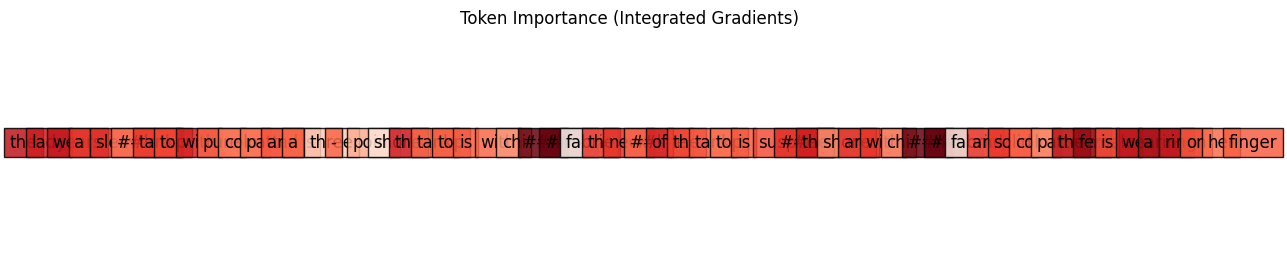

In [70]:
plt.figure(figsize=(16, 3))

x = 0
for tok, score in zip(tokens, scores):
    plt.text(x, 0, tok,
             fontsize=12,
             bbox=dict(facecolor=plt.cm.Reds(score), alpha=0.85),
             ha='left')
    x += 1.2   # fixed spacing → cleaner

plt.xlim(0, x)
plt.ylim(-1, 1)
plt.axis('off')
plt.title("Token Importance (Integrated Gradients)")
plt.show()

In [71]:
attn = attn_weights[0].mean(0).squeeze()  # avg heads

for tok, score in zip(tokens, attn):
    print(f"{tok}: {score.item():.4f}")

the: 0.0028
lady: 0.0049
wears: 0.0032
a: 0.0003
sleeve: 0.0004
##less: 0.0006
tank: 0.0007
top: 0.0007
with: 0.0008
pure: 0.0013
color: 0.0008
patterns: 0.0004
and: 0.0011
a: 0.0023
three: 0.0009
-: 0.0025
point: 0.0017
shorts: 0.0018
the: 0.0056
tank: 0.0008
top: 0.0005
is: 0.0006
with: 0.0010
chi: 0.0020
##ff: 0.0062
##on: 0.1580
fabric: 0.0514
the: 0.0610
neck: 0.0100
##line: 0.0008
of: 0.0018
the: 0.0038
tank: 0.0028
top: 0.0038
is: 0.0009
suspend: 0.0009
##ers: 0.0016
the: 0.0027
shorts: 0.0032
are: 0.0025
with: 0.0008
chi: 0.0032
##ff: 0.0216
##on: 0.0065
fabric: 0.0156
and: 0.2572
solid: 0.1030
color: 0.1304
patterns: 0.0671
the: 0.0210
female: 0.0070
is: 0.0026
wearing: 0.0035
a: 0.0008
ring: 0.0005
on: 0.0013
her: 0.0004
finger: 0.0007


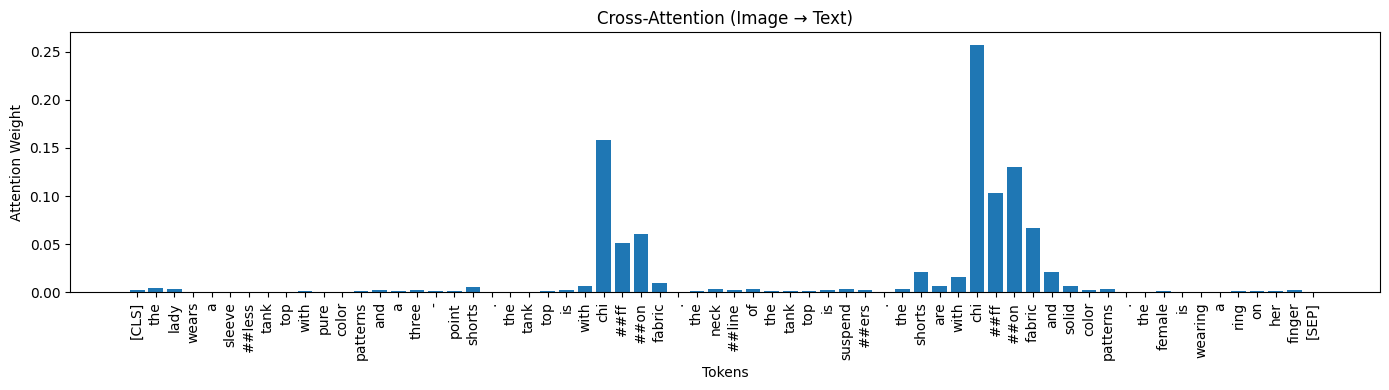

In [72]:
import matplotlib.pyplot as plt

tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
attn = attn_weights[0].mean(0).squeeze().detach().cpu().numpy()

plt.figure(figsize=(14,4))
plt.bar(range(len(tokens)), attn)

plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.title("Cross-Attention (Image → Text)")
plt.xlabel("Tokens")
plt.ylabel("Attention Weight")

plt.tight_layout()
plt.show()

## Evaluation

                     precision    recall  f1-score   support

     Blouses_Shirts       0.78      0.80      0.79       181
          Cardigans       0.68      0.60      0.64        47
              Denim       0.29      0.14      0.19        14
            Dresses       0.91      0.93      0.92       191
       Graphic_Tees       0.66      0.64      0.65        33
      Jackets_Coats       0.83      0.87      0.85        45
      Jackets_Vests       0.87      0.87      0.87        15
           Leggings       0.12      0.14      0.13         7
              Pants       0.79      0.80      0.80        51
  Rompers_Jumpsuits       0.78      0.72      0.75        39
       Shirts_Polos       0.63      0.63      0.63        19
             Shorts       0.79      0.85      0.82        88
             Skirts       1.00      1.00      1.00        45
           Sweaters       0.66      0.74      0.70        88
Sweatshirts_Hoodies       0.82      0.58      0.68        24
         Tees_Tanks    

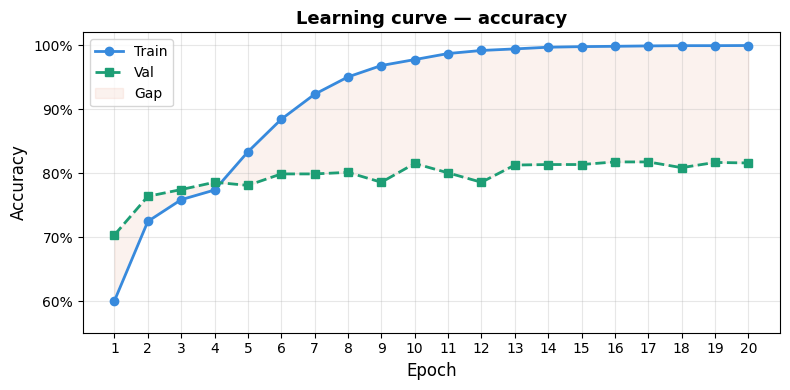

Saved → vit_learning_curve.png


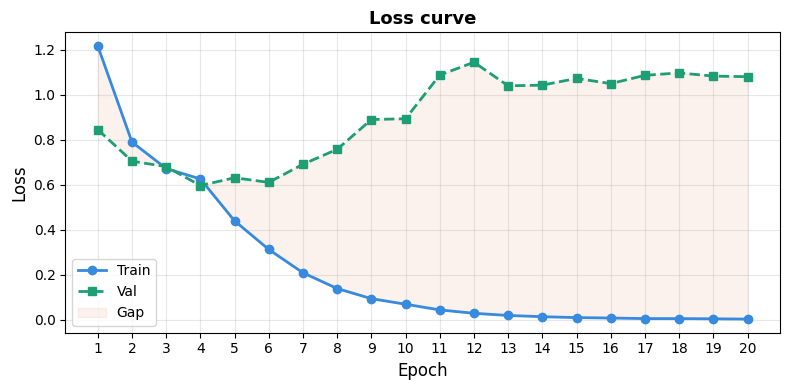

Saved → vit_loss_curve.png


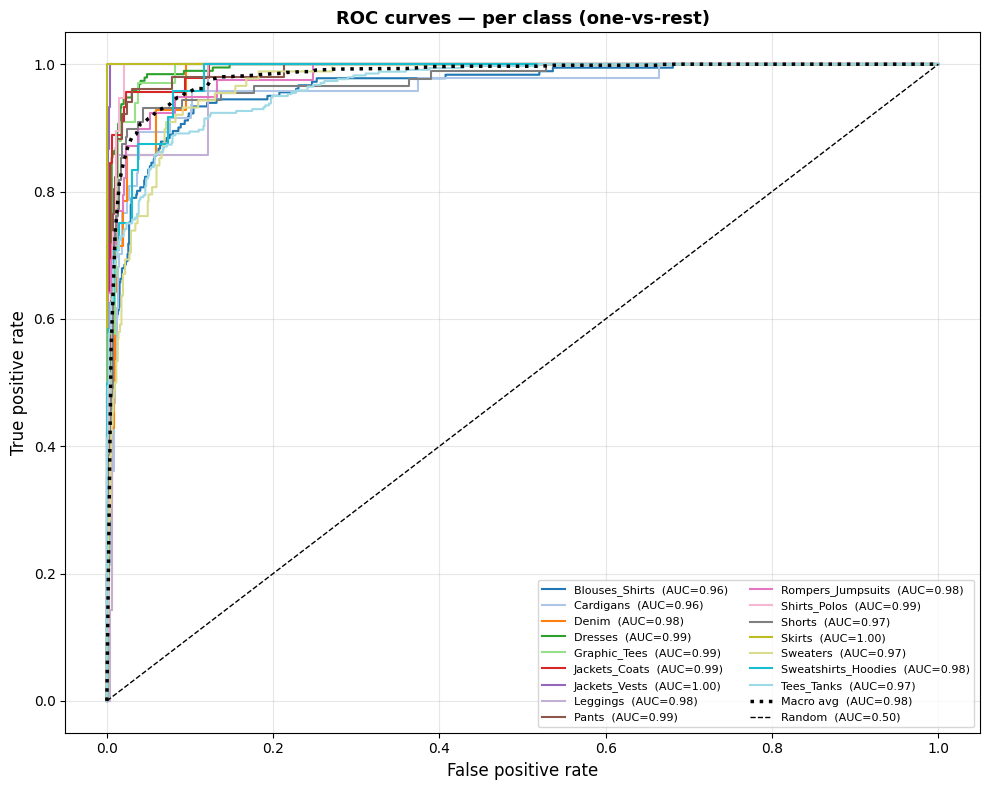

Saved → vit_roc_curves.png


In [73]:
# Classification report
from sklearn.metrics import classification_report

vit_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, input_ids, attention_mask, labels in vit_test_loader:
        images, input_ids      = images.to(DEVICE), input_ids.to(DEVICE)
        attention_mask, labels = attention_mask.to(DEVICE), labels.to(DEVICE)
        logits = vit_model(images, input_ids, attention_mask)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

idx_to_class   = {v: k for k, v in vit_test_dataset.class_to_idx.items()}
present_labels = sorted(set(all_labels))
target_names   = [idx_to_class[i] for i in present_labels]
print(classification_report(all_labels, all_preds,
                             labels=present_labels, target_names=target_names))

# Learning curves and ROC
plot_learning_curve(vit_logger.history, save_path="vit_learning_curve.png")
plot_loss_curve(vit_logger.history,     save_path="vit_loss_curve.png")
plot_roc_curves(vit_model, vit_test_loader, vit_test_dataset, DEVICE,
                save_path="vit_roc_curves.png")